<a href="https://colab.research.google.com/github/ggyupi/PCVK_Ganjil_2025/blob/main/PERCOBAAN_HISTOGRAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D1 PERCOBAAN HISTOGRAM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

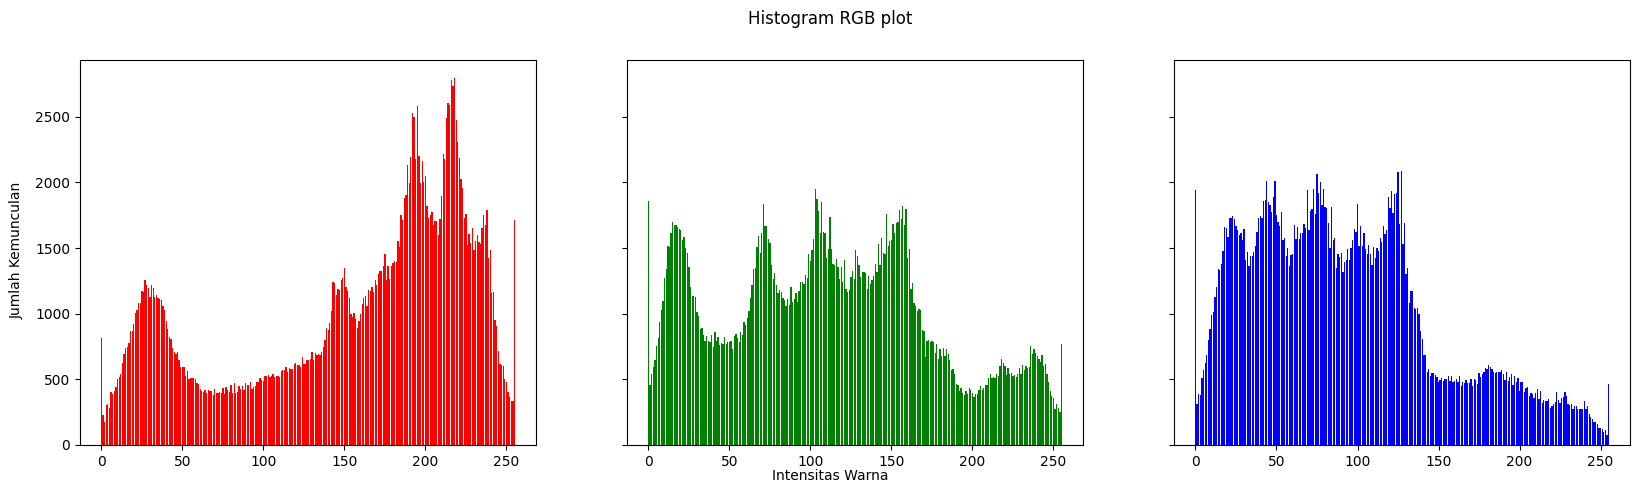

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


# PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?
2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

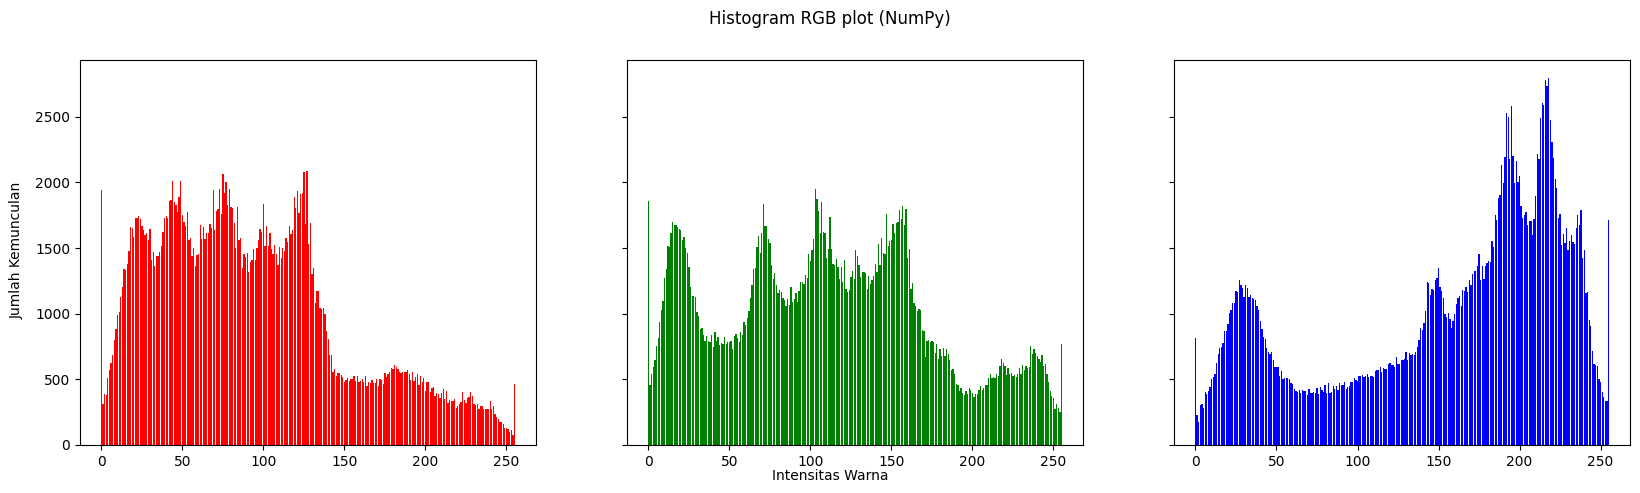

In [ ]:
b,g,r = cv.split(img)
names = np.arange(256)

red = np.histogram(r.flatten(), bins=256, range=[0, 256])[0]
green = np.histogram(g.flatten(), bins=256, range=[0, 256])[0]
blue = np.histogram(b.flatten(), bins=256, range=[0, 256])[0]

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

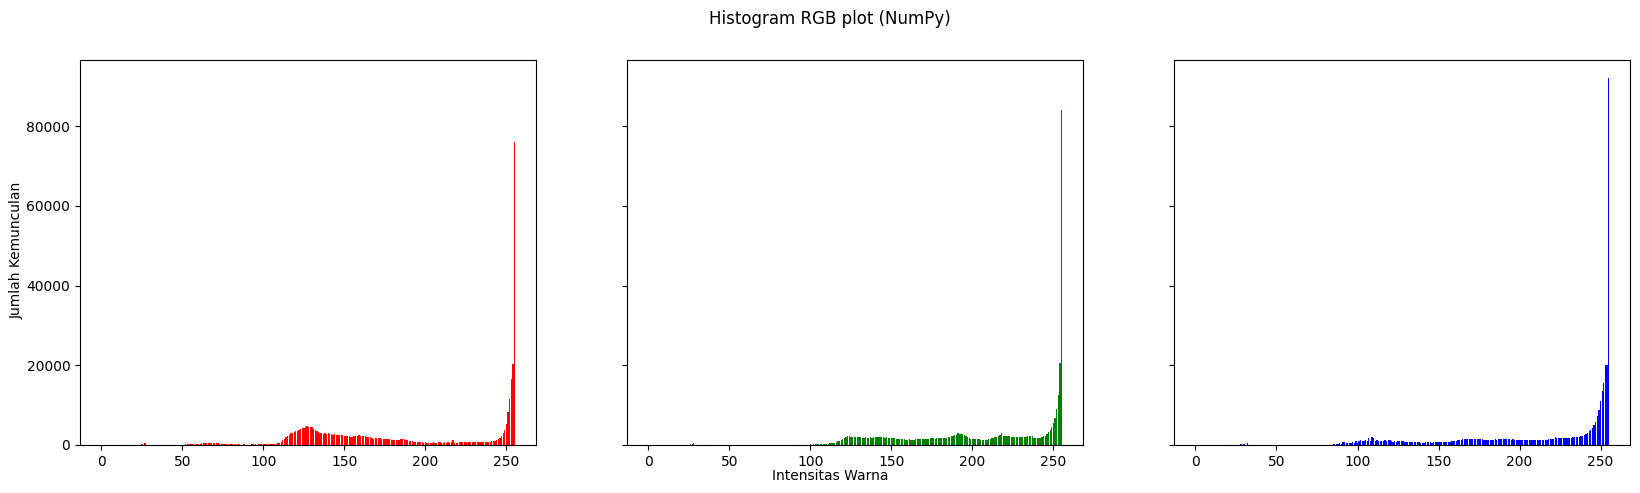

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/images/KTM_lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

names = np.arange(256)

r = img[:,:,0].ravel()
g = img[:,:,1].ravel()
b = img[:,:,2].ravel()

red, _ = np.histogram(r, bins=256, range=(0,256))
green, _ = np.histogram(g, bins=256, range=(0,256))
blue, _ = np.histogram(b, bins=256, range=(0,256))

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')
plt.show()

Gambar cenderung sangat terang, karena hampir semua nilai piksel berada di kanan. Kontras juga relatif rendah karena distribusi nilai tidak merata, sehingga di area gelap hampir tidak muncul.

# D2 PERCOBAAN HISTOGRAM EQUALIZATION

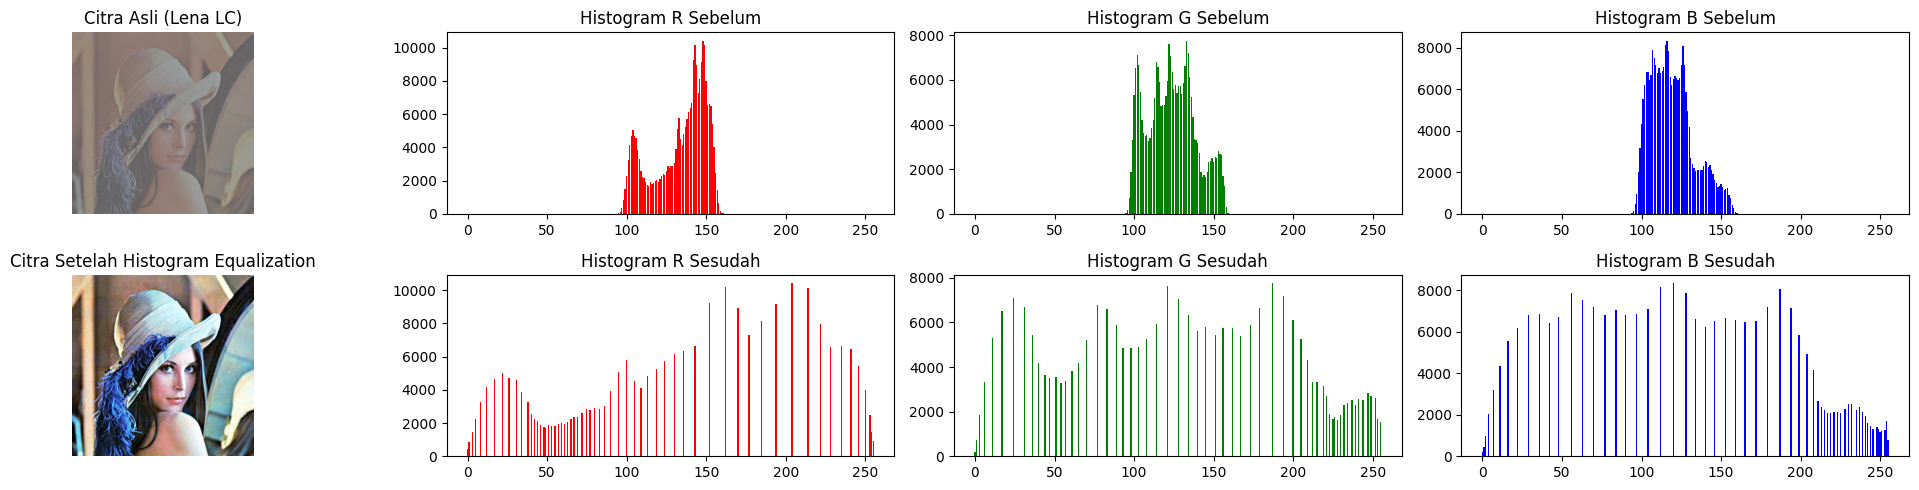

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

equ = cv.merge([r_eq, g_eq, b_eq])

# Hitung histogram sebelum
red_hist, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
red_hist_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
green_hist_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
blue_hist_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))

names = np.arange(256)

fig, axs = plt.subplots(2, 4, figsize=(20,5))

axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, red_hist, color='red')
axs[0,1].set_title("Histogram R Sebelum")

axs[0,2].bar(names, green_hist, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, blue_hist, color='blue')
axs[0,3].set_title("Histogram B Sebelum")

axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, red_hist_eq, color='red')
axs[1,1].set_title("Histogram R Sesudah")

axs[1,2].bar(names, green_hist_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, blue_hist_eq, color='blue')
axs[1,3].set_title("Histogram B Sesudah")

plt.tight_layout()
plt.show()

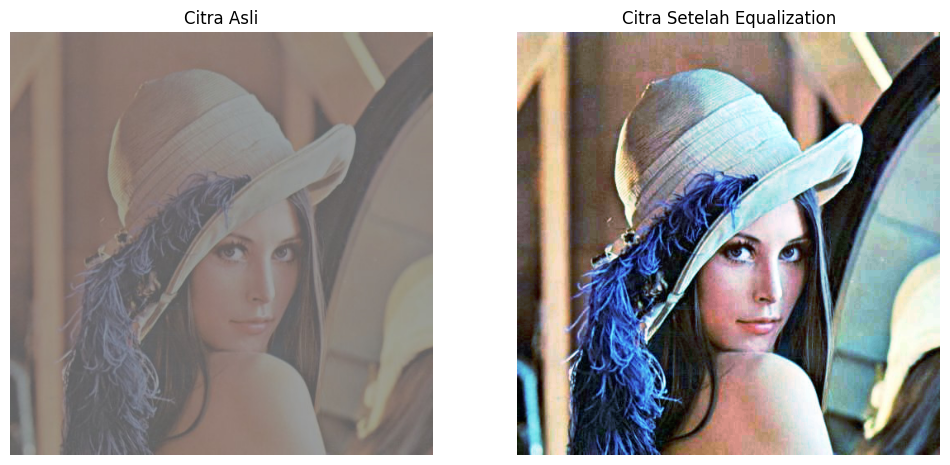

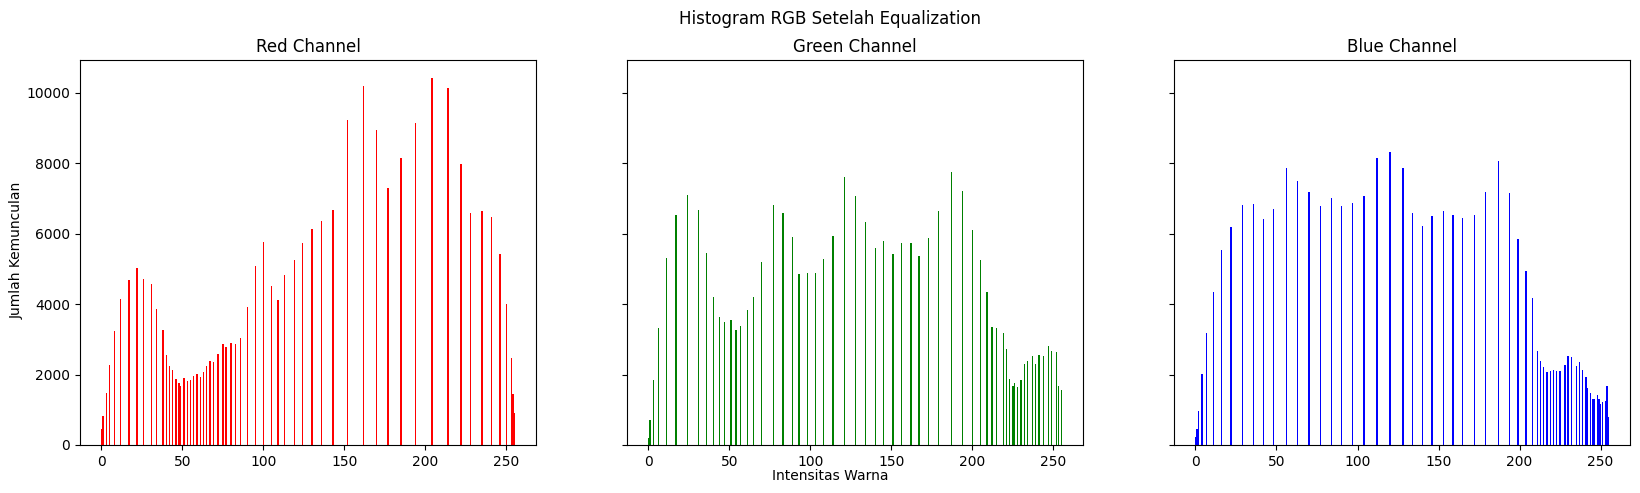

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

r_equalized = cv.equalizeHist(r)
g_equalized = cv.equalizeHist(g)
b_equalized = cv.equalizeHist(b)

equ_img = cv.merge((r_equalized, g_equalized, b_equalized))

names = np.arange(256)
red_equalized, _ = np.histogram(r_equalized.ravel(), bins=256, range=(0,256))
green_equalized, _ = np.histogram(g_equalized.ravel(), bins=256, range=(0,256))
blue_equalized, _ = np.histogram(b_equalized.ravel(), bins=256, range=(0,256))

fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].imshow(img)
ax[0].set_title("Citra Asli")
ax[0].axis("off")

ax[1].imshow(equ_img)
ax[1].set_title("Citra Setelah Equalization")
ax[1].axis("off")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Setelah Equalization')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axes[0].bar(names, red_equalized, color='red')
axes[0].set_title("Red Channel")
axes[1].bar(names, green_equalized, color='green')
axes[1].set_title("Green Channel")
axes[2].bar(names, blue_equalized, color='blue')
axes[2].set_title("Blue Channel")

plt.show()

# Pertanyaan Praktikum D2
1. Perbandingan Citra Lena

a. Gunakan hasil histogram equalization pada citra lena.jpg.

b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

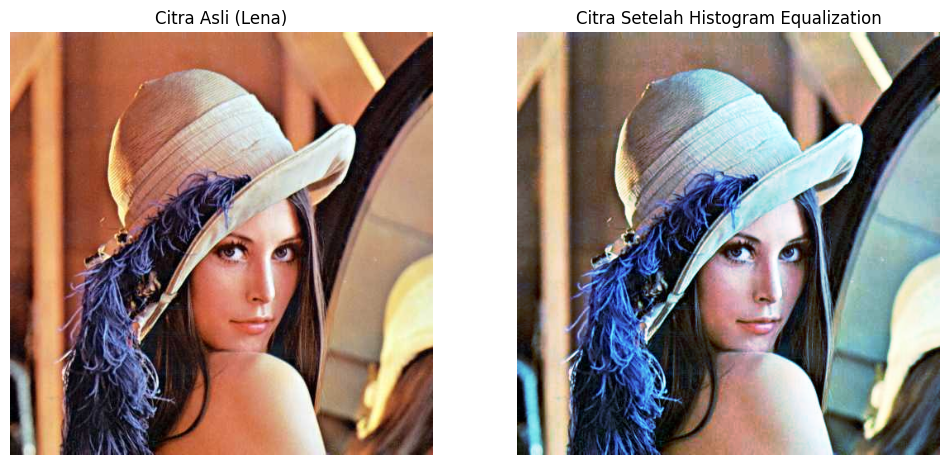

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
r, g, b = cv.split(img)

# Histogram equalization
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
equ_img = cv.merge((r_eq, g_eq, b_eq))

# Tampilkan citra asli dan hasil equalization
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(img)
axes[0].set_title("Citra Asli (Lena)")
axes[0].axis("off")

axes[1].imshow(equ_img)
axes[1].set_title("Citra Setelah Histogram Equalization")
axes[1].axis("off")
plt.show()

In [ ]:
mse = np.mean((img.astype(np.float64) - equ_img.astype(np.float64)) ** 2)

if mse == 0:
    psnr = float('inf')
else:
    psnr = 10 * np.log10((255 ** 2) / mse)

print("MSE:", mse)
print("PSNR:", psnr, "dB")


MSE: 1042.8941040039062
PSNR: 17.948401486845306 dB


c. nilai PSNR = 17.95 dB, artinya kualitas citra hasil histogram equalization cukup rendah dibandingkan dengan citra asli.

2. Gunakan Citra KTM Lama.jpg

a. Terapkan histogram equalization pada citra KTM lama.jpg.

b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.

c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization. Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah, teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas informasi dari citra atau justru membuat citra terlihat terlalu “keras”.


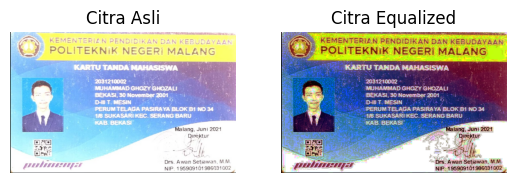

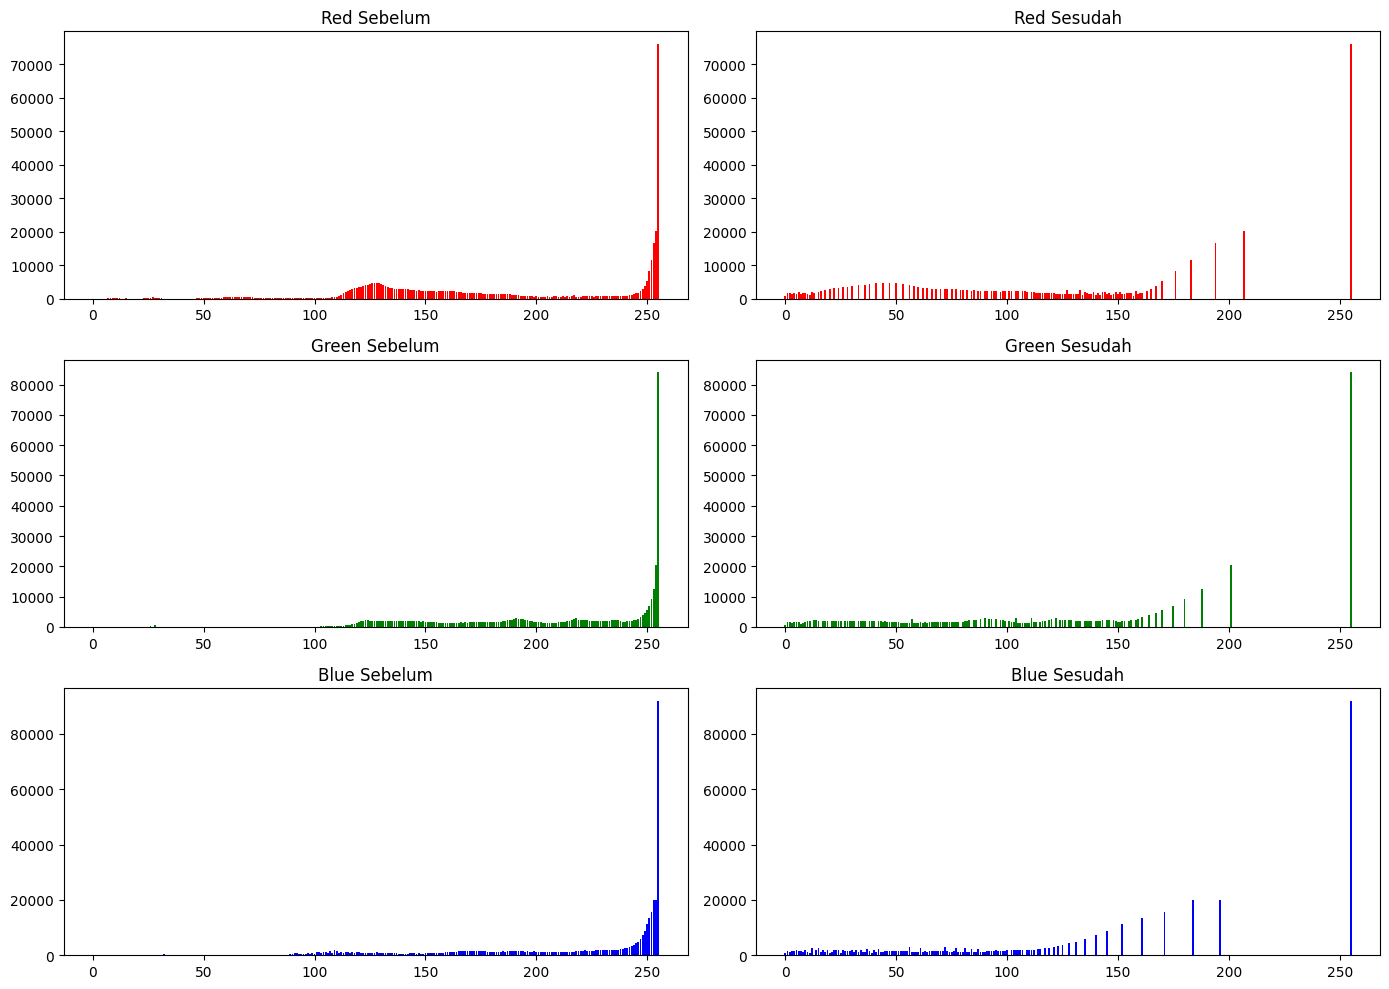

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('/content/drive/MyDrive/PCVK/images/KTM_lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

equ_img = cv.merge((r_eq, g_eq, b_eq))

names = np.arange(256)

hist_r, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
hist_g, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
hist_b, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

hist_r_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
hist_g_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
hist_b_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equ_img)
plt.title("Citra Equalized")
plt.axis("off")
plt.show()
fig, axes = plt.subplots(3, 2, figsize=(14,10))

axes[0,0].bar(names, hist_r, color='red')
axes[0,0].set_title("Red Sebelum")
axes[0,1].bar(names, hist_r_eq, color='red')
axes[0,1].set_title("Red Sesudah")

axes[1,0].bar(names, hist_g, color='green')
axes[1,0].set_title("Green Sebelum")
axes[1,1].bar(names, hist_g_eq, color='green')
axes[1,1].set_title("Green Sesudah")

axes[2,0].bar(names, hist_b, color='blue')
axes[2,0].set_title("Blue Sebelum")
axes[2,1].bar(names, hist_b_eq, color='blue')
axes[2,1].set_title("Blue Sesudah")

plt.tight_layout()
plt.show()


c. Citra asli terlihat lebih lembut namun detail teks dan wajah agak redup, sedangkan setelah equalization kontras meningkat sehingga teks dan wajah lebih jelas, tetapi warnanya tampak lebih keras dan kurang natural. Jadi kualitas informasi meningkat, tapi estetika visual berkurang.

# D3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

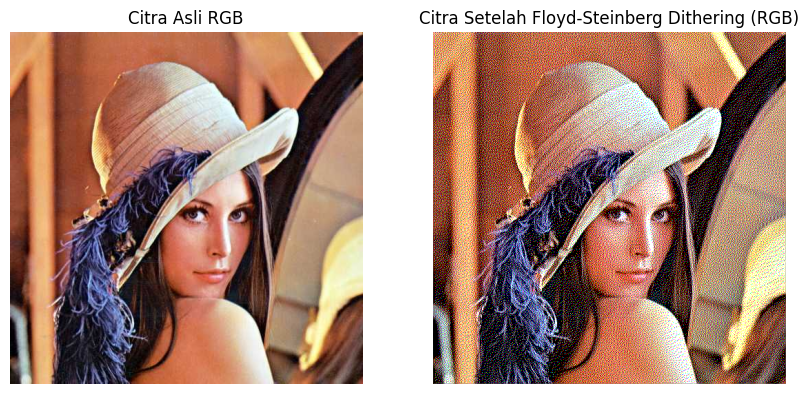

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)
channels = [r, g, b]
dithered_channels = []

def floyd_steinberg(channel):
    h, w = channel.shape
    dithered = channel.copy().astype(float)
    for y in range(h-1):
        for x in range(1, w-1):
            old_pixel = dithered[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x] = new_pixel
            error = old_pixel - new_pixel

            dithered[y, x+1] += error * 7/16
            dithered[y+1, x-1] += error * 3/16
            dithered[y+1, x] += error * 5/16
            dithered[y+1, x+1] += error * 1/16
    return np.clip(dithered, 0, 255).astype(np.uint8)

for c in channels:
    dithered_channels.append(floyd_steinberg(c))

dithered_img = cv.merge(dithered_channels)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dithered_img)
plt.title("Citra Setelah Floyd-Steinberg Dithering (RGB)")
plt.axis("off")

plt.show()


2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

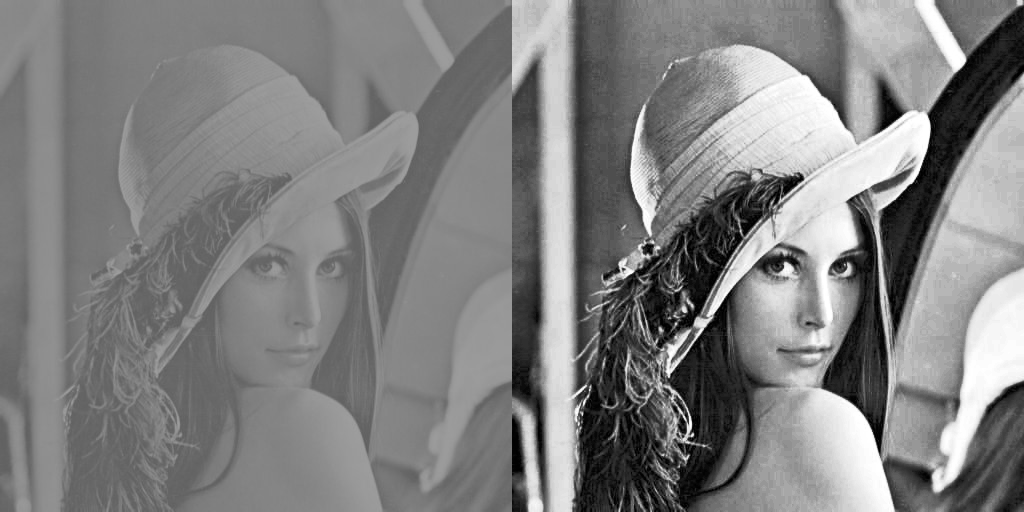

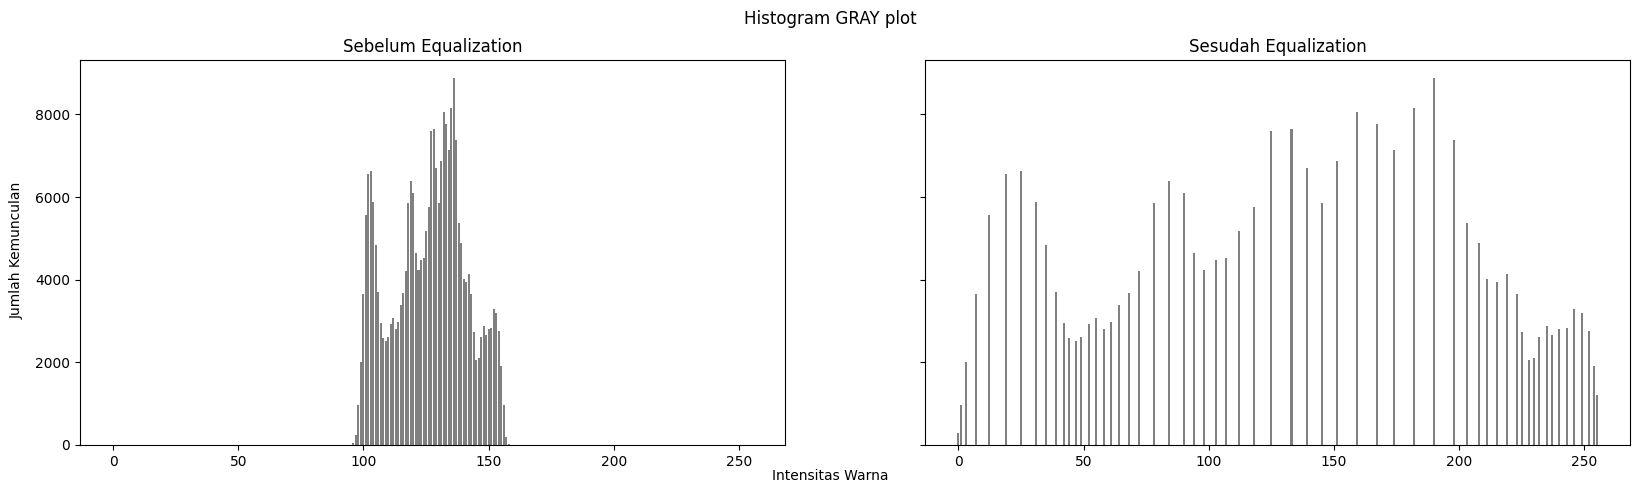

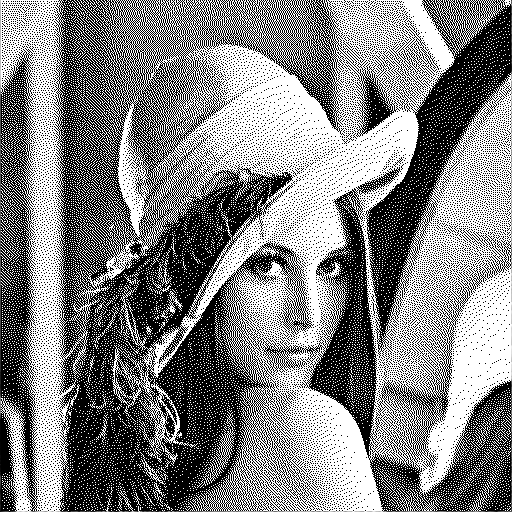

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Baca citra grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/images/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

# Histogram asli
hist_asli, _ = np.histogram(img.ravel(), bins=256, range=(0,256))

# Histogram Equalization
img_eq = cv.equalizeHist(img)
hist_eq, _ = np.histogram(img_eq.ravel(), bins=256, range=(0,256))

# Gabungkan citra asli dan equalized
img_bgr = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
img_eq_bgr = cv.cvtColor(img_eq, cv.COLOR_GRAY2BGR)
final_frame = cv.hconcat((img_bgr, img_eq_bgr))
cv2_imshow(final_frame)

# Plot histogram
names = np.arange(256)
fig, axes = plt.subplots(1, 2, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram GRAY plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, hist_asli, color='gray')
axes[0].set_title("Sebelum Equalization")
axes[1].bar(names, hist_eq, color='gray')
axes[1].set_title("Sesudah Equalization")
plt.show()

# Floyd–Steinberg dithering
def floyd_steinberg_dithering(image):
    h, w = image.shape
    dithered = image.astype(float).copy()
    for y in range(h-1):
        for x in range(1, w-1):
            old_pixel = dithered[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x] = new_pixel
            error = old_pixel - new_pixel

            dithered[y, x+1] += error * 7/16
            dithered[y+1, x-1] += error * 3/16
            dithered[y+1, x]   += error * 5/16
            dithered[y+1, x+1] += error * 1/16

    return np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil dithering
dithered_gray_image = floyd_steinberg_dithering(img_eq)
cv2_imshow(dithered_gray_image)
